In [ ]:
from ultralytics import YOLO
import glob
import os
import pickle 
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import PIL

In [2]:
def load_model(model_path):
    
    model= YOLO(model_path)
    print(f"Model has been loaded!")
    return model

model= load_model(model_path='../output/model/model.pt')

Model has been loaded!


In [3]:
# validate the files in 'val'

files= sorted(glob.glob("../dataset/Processed/images/val/*.png", recursive=True))
labels= sorted(glob.glob("../dataset/Processed/labels/val/*.txt", recursive=True))

assert len(files) == len(labels)
print(f"Total files found: {len(files)}, Total labels found: {len(labels)}")

Total files found: 3800, Total labels found: 3800


In [4]:
# create gt and pred image_id to attributes map
def load_model(model_path):
    
    model= YOLO(model_path)
    print(f"Model has been loaded!")
    return model


def prepare_evaluation_data(image_files, conf=0.3, iou=0.5, imgsz=512):
    gt_boxes = {}
    pred_boxes = {}

    output_dir = "../output/Inference-Results"
    os.makedirs(output_dir, exist_ok=True)

    results = model.predict(image_files,
                            conf=conf,
                            iou=iou,
                            imgsz=imgsz,
                            batch=16,   
                            stream=True,
                            verbose=False
                           )
    
    for im_file, result in zip(image_files, results):

        image_id = os.path.splitext(os.path.basename(im_file))[0]

        # ---------------- GT ----------------
        gt_data = []
        label_file = im_file.replace("images", "labels").replace(".png", ".txt")

        if os.path.exists(label_file):
            with open(label_file, 'r') as f:
                for line in f:
                    values = line.strip().split()
                    gt_label = int(values[0])
                    x, y, w, h = map(float, values[1:])
                    gt_data.append({
                        "bbox": [x, y, w, h],
                        "class": gt_label
                    })

        gt_boxes[image_id] = gt_data

        # ---------------- PRED ----------------
        #result = model.predict(im_file, conf=conf, iou=iou, imgsz=imgsz, verbose=False)[0]

        pred_data = []

        if result.boxes is not None and len(result.boxes) > 0:
            bboxes = result.boxes.xywhn.cpu().numpy()
            cls = result.boxes.cls.cpu().numpy()
            scores = result.boxes.conf.cpu().numpy()  

            for bbox, c, score in zip(bboxes, cls, scores):
                pred_data.append({
                    "bbox": bbox.tolist(),
                    "class": int(c.item()),
                    "score": float(score)
                })

        pred_boxes[image_id] = pred_data

    with open(f"{output_dir}/preds.pkl", "wb") as f:
        pickle.dump(pred_boxes, f)

    with open(f"{output_dir}/gt.pkl", "wb") as f:
        pickle.dump(gt_boxes, f)

    print(f"Successfully saved pkl files in '{output_dir}'")

#prepare_evaluation_data(files, conf= 0.3, iou=0.5, imgsz= 512)

In [5]:
with open("../output/Inference-Results/preds.pkl", 'rb') as f:
    det_boxes= pickle.load(f)

with open("../output/Inference-Results/gt.pkl", 'rb') as f:
    gt_boxes= pickle.load(f)

### Detection Performance

In [6]:
# lets assume pred or actual has (xmin,ymin,xmax,ymax) coordinates
# ---------------------------------------
# IoU FUNCTION (expects xyxy format)
# ---------------------------------------
def get_iou(pred, actual):
    # unpack coordinates
    gt_x1, gt_y1, gt_x2, gt_y2 = actual
    pred_x1, pred_y1, pred_x2, pred_y2 = pred

    # intersection box
    xmin = max(gt_x1, pred_x1)
    ymin = max(gt_y1, pred_y1)
    xmax = min(gt_x2, pred_x2)
    ymax = min(gt_y2, pred_y2)

    # no overlap case
    if xmax <= xmin or ymax <= ymin:
        return 0.0

    # intersection area
    intersection_area = (xmax - xmin) * (ymax - ymin)

    # individual areas
    gt_area = (gt_x2 - gt_x1) * (gt_y2 - gt_y1)
    pred_area = (pred_x2 - pred_x1) * (pred_y2 - pred_y1)

    # union
    union_area = gt_area + pred_area - intersection_area

    if union_area == 0:
        return 0.0

    # IoU
    return intersection_area / union_area


# ---------------------------------------
# Convert YOLO (xywh) → (xyxy)
# (still normalized, NOT un-normalized)
# ---------------------------------------
def convert_coords(bbox):
    x, y, w, h = bbox
    x1 = x - w / 2
    y1 = y - h / 2
    x2 = x + w / 2
    y2 = y + h / 2
    return [x1, y1, x2, y2]


def compute_mAP(det_boxes, gt_boxes, class_map, iou_threshold=0.5, method="area"):

    aps = []
    final_results = {}

    for cls_id, label in class_map.items():

        # ---------------------------------------
        # 1. Collect detections of this class
        # ---------------------------------------
        cls_dets = [
            (image_id, det)
            for image_id in det_boxes
            for det in det_boxes[image_id]
            if det['class'] == cls_id
        ]

        cls_dets = sorted(cls_dets, key=lambda x: x[1]['score'], reverse=True)

        # ---------------------------------------
        # 2. Collect GT of this class
        # ---------------------------------------
        gt_per_class = {}
        gt_matched = {}

        for image_id in gt_boxes:
            gt_list = [
                gt for gt in gt_boxes[image_id]
                if gt['class'] == cls_id
            ]

            if len(gt_list) > 0:
                gt_per_class[image_id] = gt_list
                gt_matched[image_id] = [False] * len(gt_list)

        num_gts = sum(len(v) for v in gt_per_class.values())

        # ---------------------------------------
        # Edge case: no GT
        # ---------------------------------------
        if num_gts == 0:
            final_results[label] = {
                "AP": 0.0,
                "TP": 0,
                "FP": len(cls_dets),
                "FN": 0,
                "num_gts": 0
            }
            aps.append(0.0)
            continue

        # ---------------------------------------
        # 3. TP / FP arrays
        # ---------------------------------------
        tp = np.zeros(len(cls_dets))
        fp = np.zeros(len(cls_dets))

        # ---------------------------------------
        # 4. Matching
        # ---------------------------------------
        for det_idx, (image_id, det_pred) in enumerate(cls_dets):

            pred_box = convert_coords(det_pred['bbox'])

            if image_id not in gt_per_class:
                fp[det_idx] = 1
                continue

            gt_list = gt_per_class[image_id]

            max_iou = 0.0
            max_idx = -1

            for i, gt in enumerate(gt_list):
                gt_box = convert_coords(gt['bbox'])
                iou = get_iou(pred_box, gt_box)

                if iou > max_iou:
                    max_iou = iou
                    max_idx = i

            if max_iou >= iou_threshold:
                if not gt_matched[image_id][max_idx]:
                    tp[det_idx] = 1
                    gt_matched[image_id][max_idx] = True
                else:
                    fp[det_idx] = 1
            else:
                fp[det_idx] = 1

        # ---------------------------------------
        # 5. Precision-Recall
        # ---------------------------------------
        tp = np.cumsum(tp)
        fp = np.cumsum(fp)

        eps = np.finfo(np.float32).eps

        recalls = tp / np.maximum(num_gts, eps)
        precisions = tp / np.maximum(tp + fp, eps)

        # ---------------------------------------
        # 6. AP calculation
        # ---------------------------------------
        if method == "area":
            recalls = np.concatenate(([0], recalls, [1]))
            precisions = np.concatenate(([0], precisions, [0]))

            for i in range(len(precisions) - 1, 0, -1):
                precisions[i - 1] = np.maximum(precisions[i - 1], precisions[i])

            i = np.where(recalls[1:] != recalls[:-1])[0]
            ap = np.sum((recalls[i + 1] - recalls[i]) * precisions[i + 1])

        elif method == "interp":
            ap = 0.0
            for t in np.arange(0, 1.01, 0.1):
                p = precisions[recalls >= t]
                ap += p.max() if p.size > 0 else 0.0
            ap /= 11.0

        else:
            raise ValueError("Invalid method")

        # ---------------------------------------
        # 7. Final stats
        # ---------------------------------------
        total_tp = int(tp[-1]) if len(tp) > 0 else 0
        total_fp = int(fp[-1]) if len(fp) > 0 else 0
        total_fn = int(num_gts - total_tp)

        final_results[label] = {
            "AP": ap,
            "TP": total_tp,
            "FP": total_fp,
            "FN": total_fn,
            "num_gts": num_gts
        }

        aps.append(ap)

    # ---------------------------------------
    # Overall mAP
    # ---------------------------------------
    meanAP = np.mean(aps)

    print(f"\nmAP@{iou_threshold}: {meanAP:.4f}")

    return final_results
    
class_report= compute_mAP(det_boxes, gt_boxes, class_map= model.names, iou_threshold= 0.5, method= "area")


mAP@0.5: 0.2152


In [7]:
df = pd.DataFrame.from_dict(class_report, orient='index').round(4)
#df = df.sort_values(by="AP", ascending=False)
df = df.reset_index().rename(columns={"index": "class"})
df

,class,AP,TP,FP,FN,num_gts
0,Fixed-wing Aircraft,0.4293,10,2,12,22
1,Small Aircraft,0.5657,13,5,9,22
2,Passenger/Cargo Plane,0.7639,96,13,26,122
3,Helicopter,0.4000,6,0,9,15
4,Passenger Vehicle,0.0000,0,5,294,294
5,Small Car,0.6922,34491,11441,9655,44146
6,Bus,0.4163,892,586,818,1710
7,Pickup Truck,0.0026,1,3,379,380
8,Utility Truck,0.0041,5,12,673,678
9,Truck,0.0966,675,1364,2144,2819


In [8]:
def compute_coco_mAP(det_boxes, gt_boxes, class_map, method="area"):

    iou_thresholds = np.arange(0.5, 0.96, 0.05)

    ap_table = {cls_name: [] for cls_name in class_map.values()}

    # ---------------------------------------
    # Loop over IoU thresholds
    # ---------------------------------------
    for iou_thr in iou_thresholds:

        results = compute_mAP(
            det_boxes,
            gt_boxes,
            class_map,
            iou_threshold=iou_thr,
            method=method
        )

        for cls_name, res in results.items():
            ap_table[cls_name].append(res["AP"])

    # ---------------------------------------
    # Aggregate results
    # ---------------------------------------
    final_results = {}

    aps_50 = []
    aps_5095 = []

    for cls_name, ap_list in ap_table.items():

        ap_50 = ap_list[0]  # IoU = 0.50
        ap_5095 = np.mean(ap_list)

        final_results[cls_name] = {
            "AP@0.5": ap_50,
            "AP@0.5:0.95": ap_5095
        }

        aps_50.append(ap_50)
        aps_5095.append(ap_5095)

    # ---------------------------------------
    # Overall metrics
    # ---------------------------------------
    mAP_50 = np.mean(aps_50)
    mAP_5095 = np.mean(aps_5095)

    print("\nFinal COCO Metrics:")
    print(f"mAP@0.5     : {mAP_50:.4f}")
    print(f"mAP@0.5:0.95: {mAP_5095:.4f}")

    return final_results


mAP_report= compute_coco_mAP(det_boxes, gt_boxes, class_map= model.names)


mAP@0.5: 0.2152

mAP@0.55: 0.2077

mAP@0.6000000000000001: 0.1993

mAP@0.6500000000000001: 0.1825

mAP@0.7000000000000002: 0.1623

mAP@0.7500000000000002: 0.1304

mAP@0.8000000000000003: 0.0887

mAP@0.8500000000000003: 0.0480

mAP@0.9000000000000004: 0.0173

mAP@0.9500000000000004: 0.0015

Final COCO Metrics:
mAP@0.5     : 0.2152
mAP@0.5:0.95: 0.1253


#### **Evaluation**

The model achieves an mAP of 0.21, indicating overall weak detection performance across classes. While the precision of 0.52 suggests that a reasonable proportion of predicted detections are correct, the recall of 0.27 highlights a significant limitation in detecting all relevant objects. This indicates that the model is relatively conservative—favoring fewer, more confident predictions—but failing to capture a large portion of ground truth instances. 

The low recall is likely influenced by the characteristics of the xView dataset, particularly the prevalence of small, densely packed objects and inter-class similarity, which make detection and localization more challenging. Overall, the primary bottleneck of the model lies in insufficient detection coverage rather than excessive false positives, suggesting that future improvements should focus on enhancing recall, especially for small objects.

In [9]:
def summarize_errors(det_boxes, gt_boxes, iou_threshold=0.5):

    summary = {
        "TP": 0,
        "FP": 0,
        "FN": 0,
        "CLS_ERR": 0,
        "LOC_ERR": 0
    }

    for image_id in gt_boxes.keys():

        preds = det_boxes.get(image_id, [])
        gts = gt_boxes[image_id]

        # ---------------------------
        # No GT → all FP
        # ---------------------------
        if len(gts) == 0:
            summary["FP"] += len(preds)
            continue

        gt_matched = [False] * len(gts)

        # ---------------------------
        # Prediction loop
        # ---------------------------
        for pred in preds:
            pred_box = convert_coords(pred['bbox'])
            pred_class = pred['class']

            max_iou = 0.0
            max_idx = -1

            for i, gt in enumerate(gts):
                gt_box = convert_coords(gt['bbox'])
                iou = get_iou(pred_box, gt_box)

                if iou > max_iou:
                    max_iou = iou
                    max_idx = i

            # ---------------------------
            # Classification logic
            # ---------------------------
            if max_iou == 0:
                summary["FP"] += 1

            elif max_iou < iou_threshold:
                summary["LOC_ERR"] += 1

            else:
                gt_class = gts[max_idx]['class']

                if pred_class == gt_class:
                    if not gt_matched[max_idx]:
                        summary["TP"] += 1
                        gt_matched[max_idx] = True
                    else:
                        summary["FP"] += 1
                else:
                    summary["CLS_ERR"] += 1

        # ---------------------------
        # FN (unmatched GT)
        # ---------------------------
        for matched in gt_matched:
            if not matched:
                summary["FN"] += 1

    return summary


summary= summarize_errors(det_boxes,  gt_boxes, iou_threshold=0.5)
df = pd.DataFrame.from_dict(summary, orient='index')
df

,0
TP,97777
FP,5946
FN,57240
CLS_ERR,4899
LOC_ERR,32365


- FN → very high → recall problem (model not seeing objects)
- LOC_ERR → high → model sees objects but poorly fits boxes
- FP & CLS_ERR → relatively low

Lets further dig deeper into FN and LOC_ERR analysis

### Object Size Based Evaluation                  

In [10]:
# False Negatives Analysis
def get_size(box, img_w, img_h):
    x1, y1, x2, y2 = box

    w = (x2 - x1) * img_w
    h = (y2 - y1) * img_h
    area = w * h

    if area < 16*16:
        return "small"
    elif area < 64*64:
        return "medium"
    else:
        return "large"
        
def fn_deep_analysis(det_boxes, gt_boxes, conf_thresh= 0.3, iou_thresh=0.5, img_size= 512):

    summary = {
        "small": {"FN_no_pred": 0, "FN_iou_miss": 0},
        "medium": {"FN_no_pred": 0, "FN_iou_miss": 0},
        "large": {"FN_no_pred": 0, "FN_iou_miss": 0},
    }

    for image_id in gt_boxes.keys():

        preds = det_boxes.get(image_id, [])
        gts = gt_boxes[image_id]

        for gt in gts:

            gt_box = convert_coords(gt['bbox'])
            size = get_size(gt_box, img_h=img_size, img_w=img_size)

            best_iou = 0.0
            best_conf = 0.0

            for pred in preds:
                pred_box = convert_coords(pred['bbox'])
                iou = get_iou(pred_box, gt_box)

                if iou > best_iou:
                    best_iou = iou
                    best_conf = pred['score']

            if best_iou < 0.1:
                summary[size]["FN_no_pred"] += 1
            
            elif best_conf < conf_thresh:
                summary[size].setdefault("FN_low_conf", 0)
                summary[size]["FN_low_conf"] += 1
            
            elif best_iou < iou_thresh:
                summary[size]["FN_iou_miss"] += 1

    return summary

In [11]:
fn_summary= fn_deep_analysis(det_boxes, gt_boxes,img_size= 512)

df = pd.DataFrame.from_dict(fn_summary, orient='index')
df

,FN_no_pred,FN_iou_miss
small,12780,4144
medium,14353,16183
large,1454,3385


The error analysis reveals that the model exhibits scale-dependent failures. For small objects, the model predominantly fails at the detection stage, as indicated by a significantly higher number of FN_no_pred compared to FN_iou_miss, suggesting that these objects are often not recognized at all. For medium-sized objects, both FN_no_pred and FN_iou_miss are high and comparable, indicating instability in the model’s representation—where it inconsistently detects objects and also struggles with accurate localization. This makes medium-scale objects the most critical source of error. For large objects, the model generally succeeds in detecting them but shows higher localization errors, implying limitations in bounding box regression rather than detection capability.

Overall, the model’s primary weaknesses lie in small object detection and inconsistent feature representation at medium scales, with medium objects contributing the largest share of total errors and offering the greatest opportunity for performance improvement.

In [12]:
# check class-specific medium-sized object errors

from collections import defaultdict

def medium_class_analysis(det_boxes, gt_boxes, conf_thresh=0.25, iou_thresh=0.5, img_size= 512):

    class_stats = defaultdict(lambda: {
        "FN_no_pred": 0,
        "FN_iou_miss": 0
    })

    for image_id in gt_boxes.keys():

        preds = det_boxes.get(image_id, [])
        gts = gt_boxes[image_id]

        for gt in gts:

            gt_box = convert_coords(gt['bbox'])
            size = get_size(gt_box,img_size,img_size) 
            gt_class = gt['class']

            # focus only on medium
            if size != "medium":
                continue

            best_iou = 0.0
            best_conf = 0.0

            for pred in preds:
                pred_box = convert_coords(pred['bbox'])
                iou = get_iou(pred_box, gt_box)

                if iou > best_iou:
                    best_iou = iou
                    best_conf = pred['score']

            # classify
            if best_iou < 0.1:
                class_stats[gt_class]["FN_no_pred"] += 1

            elif best_iou < iou_thresh:
                class_stats[gt_class]["FN_iou_miss"] += 1

    return class_stats


medium_stats = medium_class_analysis(det_boxes, gt_boxes)
for cls, stats in medium_stats.items():
    print(cls, stats)

48 {'FN_no_pred': 10397, 'FN_iou_miss': 14784}
52 {'FN_no_pred': 23, 'FN_iou_miss': 8}
43 {'FN_no_pred': 26, 'FN_iou_miss': 4}
9 {'FN_no_pred': 623, 'FN_iou_miss': 133}
39 {'FN_no_pred': 62, 'FN_iou_miss': 5}
38 {'FN_no_pred': 24, 'FN_iou_miss': 4}
11 {'FN_no_pred': 131, 'FN_iou_miss': 30}
13 {'FN_no_pred': 336, 'FN_iou_miss': 87}
41 {'FN_no_pred': 2, 'FN_iou_miss': 0}
5 {'FN_no_pred': 381, 'FN_iou_miss': 393}
6 {'FN_no_pred': 171, 'FN_iou_miss': 43}
51 {'FN_no_pred': 67, 'FN_iou_miss': 25}
53 {'FN_no_pred': 277, 'FN_iou_miss': 224}
47 {'FN_no_pred': 63, 'FN_iou_miss': 8}
10 {'FN_no_pred': 411, 'FN_iou_miss': 105}
50 {'FN_no_pred': 40, 'FN_iou_miss': 12}
8 {'FN_no_pred': 118, 'FN_iou_miss': 39}
33 {'FN_no_pred': 6, 'FN_iou_miss': 1}
14 {'FN_no_pred': 79, 'FN_iou_miss': 22}
56 {'FN_no_pred': 119, 'FN_iou_miss': 26}
57 {'FN_no_pred': 140, 'FN_iou_miss': 27}
27 {'FN_no_pred': 10, 'FN_iou_miss': 3}
28 {'FN_no_pred': 28, 'FN_iou_miss': 21}
26 {'FN_no_pred': 15, 'FN_iou_miss': 2}
36 {'FN_no_

The instability observed in medium-sized objects is primarily driven by the Building class, which exhibits significant intra-class variability in scale, shape, and spatial layout. This suggests that the issue is not purely due to generic feature extraction limitations, but rather due to the model’s difficulty in learning consistent representations for objects with high scale and structural variability.

### Spatial Positiion Analysis

In [13]:
def is_near_edge(box, img_w, img_h, margin=10):
    x1, y1, x2, y2 = box

    return (
        x1 <= margin or
        y1 <= margin or
        x2 >= img_w - margin or
        y2 >= img_h - margin
    )

def count_edge_objects(gt_boxes, img_w, img_h, margin=10):

    counts = {
        "edge": 0,
        "center": 0
    }

    for image_id in gt_boxes:

        gts = gt_boxes[image_id]

        for gt in gts:
            box = convert_coords(gt['bbox'])

            # convert to pixel coords
            x1, y1, x2, y2 = box
            box_pixel = [
                x1 * img_w,
                y1 * img_h,
                x2 * img_w,
                y2 * img_h
            ]

            if is_near_edge(box_pixel, img_w, img_h, margin):
                counts["edge"] += 1
            else:
                counts["center"] += 1

    return counts

def fn_edge_analysis(det_boxes, gt_boxes, img_w, img_h):

    stats = {
        "edge": {"FN": 0},
        "center": {"FN": 0}
    }

    for image_id in gt_boxes.keys():

        preds = det_boxes.get(image_id, [])
        gts = gt_boxes[image_id]

        for gt in gts:

            gt_box = convert_coords(gt['bbox'])

            # convert to pixel coords
            x1, y1, x2, y2 = gt_box
            gt_box_pixel = [
                x1 * img_w,
                y1 * img_h,
                x2 * img_w,
                y2 * img_h
            ]

            # find best IoU (same as before)
            best_iou = 0.0
            for pred in preds:
                pred_box = convert_coords(pred['bbox'])
                iou = get_iou(pred_box, gt_box)

                if iou > best_iou:
                    best_iou = iou

            # FN condition (same logic you used)
            if best_iou < 0.5:

                if is_near_edge(gt_box_pixel, img_w, img_h):
                    stats["edge"]["FN"] += 1
                    
                else:
                    stats["center"]["FN"] += 1
                    
    return stats

object_spatial_counts= count_edge_objects(gt_boxes, img_w=512, img_h=512)
edge_stats = fn_edge_analysis(det_boxes, gt_boxes, img_w=512, img_h=512)
print("Edge Object counts: ", object_spatial_counts)
print("Edge FN Stats: ", edge_stats)

Edge Object counts:  {'edge': 45646, 'center': 109371}
Edge FN Stats:  {'edge': {'FN': 20545}, 'center': {'FN': 31754}}


There is a noticeable degradation in detection performance near tile boundaries, with edge objects having a significantly higher FN rate (~ 45%) compared to center objects (~ 29%). While tiling is not the dominant source of errors, it contributes to detection failures, likely due to object truncation and partial visibility at tile edges.

### Localization Analysis

In [14]:
def loc_error_analysis(det_boxes, gt_boxes):

    stats = {
        "LOC_near_miss": 0,
        "LOC_bad": 0
    }

    for image_id in gt_boxes:

        preds = det_boxes.get(image_id, [])
        gts = gt_boxes[image_id]

        for gt in gts:

            gt_box = convert_coords(gt['bbox'])

            best_iou = 0.0

            for pred in preds:
                pred_box = convert_coords(pred['bbox'])
                iou = get_iou(pred_box, gt_box)

                if iou > best_iou:
                    best_iou = iou

            # only consider localization errors
            if 0.1 <= best_iou < 0.5:
                if best_iou >= 0.3:
                    stats["LOC_near_miss"] += 1
                else:
                    stats["LOC_bad"] += 1

    return stats

loc_error_stats= loc_error_analysis(det_boxes, gt_boxes)
loc_error_stats

{'LOC_near_miss': 12074, 'LOC_bad': 11638}

In [15]:
from collections import defaultdict

def loc_error_with_size(det_boxes, gt_boxes, img_w, img_h, iou_thresh=0.5):

    stats = {
        "small": {"LOC_near_miss": 0, "LOC_bad": 0},
        "medium": {"LOC_near_miss": 0, "LOC_bad": 0},
        "large": {"LOC_near_miss": 0, "LOC_bad": 0},
    }

    for image_id in gt_boxes:

        preds = det_boxes.get(image_id, [])
        gts = gt_boxes[image_id]

        for gt in gts:
            gt_box_norm = convert_coords(gt['bbox'])

            # get size
            size = get_size(gt_box_norm, img_w, img_h)

            # find best IoU (normalized only)
            best_iou = 0.0
            for pred in preds:
                pred_box_norm = convert_coords(pred['bbox'])
                iou = get_iou(pred_box_norm, gt_box_norm)

                if iou > best_iou:
                    best_iou = iou

            # classify LOC error
            if 0.1 <= best_iou < iou_thresh:
                if best_iou >= 0.3:
                    stats[size]["LOC_near_miss"] += 1
                else:
                    stats[size]["LOC_bad"] += 1

    return stats

loc_size_error_stats= loc_error_with_size(det_boxes, gt_boxes, img_h= 512, img_w= 512)
loc_size_error_stats

{'small': {'LOC_near_miss': 2213, 'LOC_bad': 1931},
 'medium': {'LOC_near_miss': 7913, 'LOC_bad': 8270},
 'large': {'LOC_near_miss': 1948, 'LOC_bad': 1437}}

Localization errors are scale-dependent, with medium-scale objects exhibiting the highest instability due to inconsistent feature representation.        

Medium-sized objects are the primary source of localization errors, contributing the largest share of both near-miss and severely mislocalized predictions. The nearly equal distribution between near-miss and bad localization errors indicates instability in the model’s representation at this scale, where it inconsistently captures object geometry

### Classification Analysis

In [18]:
def classification_analysis(det_boxes, gt_boxes, class_map, iou_thresh=0.5):

    num_classes = len(class_map)
    matrix = np.zeros((num_classes + 1, num_classes + 1), dtype=int)
    bg_idx = num_classes

    for image_id in gt_boxes.keys():

        preds = det_boxes.get(image_id, [])
        gts = gt_boxes[image_id]

        pred_matched = [False] * len(preds)
        gt_matched = [False] * len(gts)

        # precompute GT boxes
        gt_boxes_xyxy = [convert_coords(gt['bbox']) for gt in gts]

        for pred_idx, pred in enumerate(preds):

            pred_box = convert_coords(pred['bbox'])
            pred_class = pred['class']

            max_iou = 0.0
            max_idx = -1

            for gt_idx, gt_box in enumerate(gt_boxes_xyxy):

                if gt_matched[gt_idx]:
                    continue

                iou = get_iou(pred_box, gt_box)

                if iou > max_iou:
                    max_iou = iou
                    max_idx = gt_idx

            if max_iou >= iou_thresh:
                gt_class = gts[max_idx]['class']

                matrix[gt_class][pred_class] += 1
                pred_matched[pred_idx] = True
                gt_matched[max_idx] = True

        # FN
        for gt_idx, matched in enumerate(gt_matched):
            if not matched:
                gt_class = gts[gt_idx]['class']
                matrix[gt_class][bg_idx] += 1

        # FP
        for pred_idx, matched in enumerate(pred_matched):
            if not matched:
                pred_class = preds[pred_idx]['class']
                matrix[bg_idx][pred_class] += 1

    return matrix


def prepare_grouped_order(class_map, group_to_classes):

    ordered_classes = []
    class_labels = []
    group_boundaries = []
    group_names = []

    count = 0

    for group, cls_list in group_to_classes.items():
        group_names.append(group)

        for cls_id in cls_list:
            ordered_classes.append(cls_id)
            class_labels.append(class_map[cls_id])

        count += len(cls_list)
        group_boundaries.append(count)

    # background
    bg_idx = len(class_map)
    ordered_classes.append(bg_idx)
    class_labels.append("background")

    return ordered_classes, class_labels, group_boundaries, group_names


def plot_grouped_confusion_matrix(matrix, class_map, group_to_classes):

    ordered_classes, class_labels, boundaries, group_names = prepare_grouped_order(class_map, group_to_classes)

    matrix = matrix[ordered_classes][:, ordered_classes]

    plt.figure(figsize=(20, 16))

    ax = sns.heatmap(
        matrix,
        cmap="Blues",
        linewidths=0.2,
        linecolor="gray",
        cbar=True,
        annot=True,
        fmt="d",
        annot_kws={"size": 7}
    )

    ax.set_xticks(np.arange(len(class_labels)) + 0.5)
    ax.set_yticks(np.arange(len(class_labels)) + 0.5)

    ax.set_xticklabels(class_labels, rotation=90, fontsize=7)
    ax.set_yticklabels(class_labels, fontsize=7)

    for b in boundaries:
        ax.axhline(b, color='black', linewidth=2)
        ax.axvline(b, color='black', linewidth=2)

    prev = 0
    for group, b in zip(group_names, boundaries):
        center = (prev + b) / 2

        ax.text(center, -2, group, ha='center', fontsize=12, fontweight='bold')
        ax.text(-2, center, group, va='center', rotation=90, fontsize=12, fontweight='bold')

        prev = b

    plt.title("Grouped Confusion Matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.show()

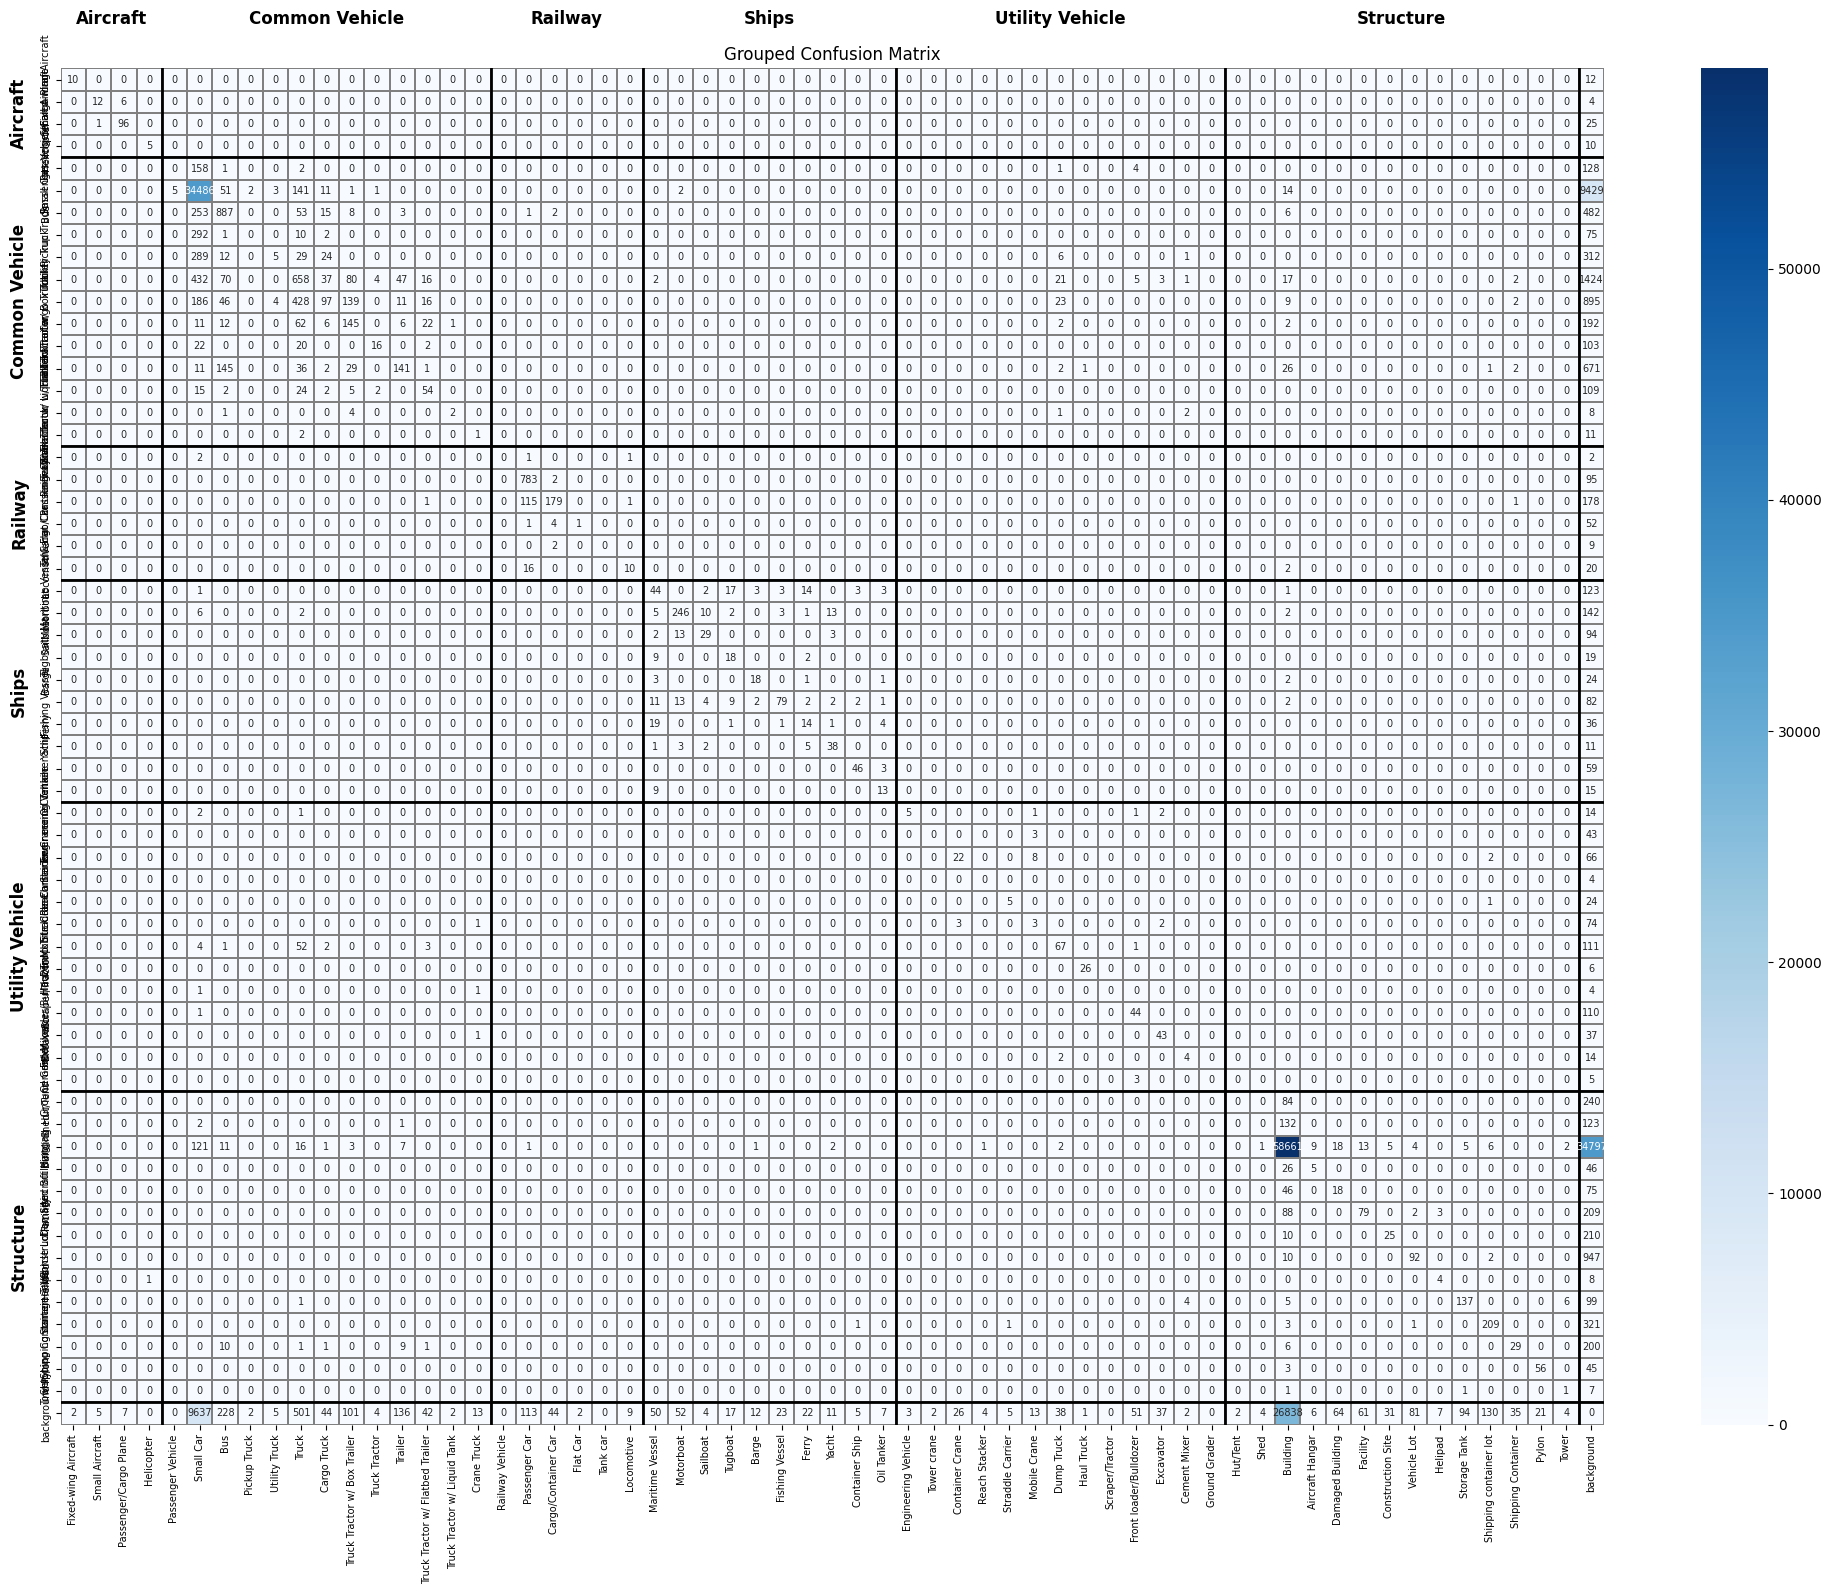

In [19]:
group_to_classes = {
    "Aircraft": [0,1,2,3],
    "Common Vehicle": list(range(4,17)),
    "Railway": list(range(17,23)),
    "Ships": list(range(23,33)),
    "Utility Vehicle": list(range(33,46)),
    "Structure": list(range(46,60))
}

matrix= classification_analysis(det_boxes=det_boxes, gt_boxes=gt_boxes, class_map=model.names, iou_thresh=0.5)
plot_grouped_confusion_matrix(matrix, class_map=model.names, group_to_classes= group_to_classes)

The confusion matrix shows that your model has learned strong high-level semantic separation between major object groups (Aircraft, Vehicles, Ships, Railway, Structures), but struggles significantly with fine-grained classification within those groups.                   

The presence of dominant classes with large sample counts indicates that the model is somewhat biased toward frequently occurring categories, leading to weaker performance on rare classes and increased misclassification into common ones. Despite this, the low cross-group confusion confirms that the dataset and training pipeline are fundamentally sound.                                   

Furthermore, the distribution of values suggests class imbalance, where high-frequency classes dominate predictions, causing:

- Increased false negatives for minority classes
- Bias toward predicting majority classes in ambiguous scenarios

From a performance standpoint, this explains a typical behavior where:

- mAP@0.5 remains relatively strong (coarse detection is correct)                       
- mAP@[0.5:0.95] degrades due to misclassification and localization sensitivity

In summary, the model demonstrates:

✅ Strong coarse-level generalization                               
⚠️ Moderate localization reliability                
❌ Weak fine-grained class discrimination              